# CMI and Markov length for a ring of Fibonacci plaquettes — optimized version

This version follows the same memory strategy as the optimized toric-code plaquette notebook:

1. represent the ground state by its non-zero computational-basis amplitudes;
2. avoid constructing any full \(2^N\times 2^N\) density matrix;
3. precompute compact reduced-density-matrix data for each region;
4. implement dephasing by multiplying matrix elements by \((1-2p)^d\), where \(d\) is the Hamming distance between the relevant error signatures.

The dense functions from the original notebook are not needed for the main calculation.

In [1]:
import os
import math
import json
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from itertools import combinations
from collections import Counter, defaultdict
from collections.abc import Iterable

os.makedirs("New_plots", exist_ok=True)

try:
    import scienceplots  # optional
    plt.style.use('science')
except Exception:
    pass

# Fibonacci constants
phi = (1.0 + np.sqrt(5.0)) / 2.0
D = np.sqrt(1.0 + phi**2)

## Geometry and Fibonacci-inspired sparse ground state

For a ring with `P` plaquettes there are `N = 3P` edge qubits. A plaquette operation flips four qubits, so on a computational basis integer it is just XOR with a plaquette bit mask.

In [2]:
def get_plaquettes(number_of_plaquettes):
    """Return plaquette qubit indices for a ring with P plaquettes and N=3P qubits."""
    P = int(number_of_plaquettes)
    return np.array([
        [(3*n) % (3*P), (3*n + 1) % (3*P), (3*n + 2) % (3*P), (3*n + 3) % (3*P)]
        for n in range(P)
    ], dtype=int)


def get_error_index(total_system_size):
    """Noise acts on shared/ring-boundary edges 0,3,6,... as in the original notebook."""
    return np.array([i for i in range(int(total_system_size)) if i % 3 == 0], dtype=int)


def flatten_integers(obj):
    if isinstance(obj, (int, np.integer)):
        yield int(obj)
    elif isinstance(obj, Iterable) and not isinstance(obj, (str, bytes)):
        for item in obj:
            yield from flatten_integers(item)


def find_repeated_integers(obj):
    """Return integers appearing more than once in a nested list/array."""
    counts = Counter(flatten_integers(obj))
    return [num for num, count in counts.items() if count > 1]


def all_subarrays(arr):
    """Original notebook rule: all contiguous subarrays of the repeated-edge list."""
    arr = list(arr)
    out = []
    for start in range(len(arr)):
        for end in range(start + 1, len(arr) + 1):
            out.append(arr[start:end])
    return out


def bit_mask(indices):
    """Integer mask with the listed qubit positions set."""
    mask = 0
    for q in indices:
        mask ^= (1 << int(q))
    return mask


def generate_fibonacci_ground_state_support(number_of_plaquettes, normalize=True):
    """
    Build the Fibonacci-inspired ground state sparsely.

    Returns
    -------
    states : np.ndarray[uint64]
        Computational-basis states with non-zero amplitude.
    amplitudes : np.ndarray[float64]
        Normalized real amplitudes.
    """
    P = int(number_of_plaquettes)
    plaquettes = get_plaquettes(P)
    plaquette_masks = [bit_mask(plaq) for plaq in plaquettes]

    amps = defaultdict(float)
    amps[0] += 1.0

    for k in range(1, P + 1):
        for combo in combinations(range(P), k):
            selected_plaquettes = [plaquettes[h].tolist() for h in combo]
            inner_edges = find_repeated_integers(selected_plaquettes)

            xmask = 0
            for h in combo:
                xmask ^= plaquette_masks[h]

            base_amp = phi**k

            if len(inner_edges) == 0:
                amps[xmask] += base_amp
            else:
                # Original notebook's Fibonacci-inspired coefficients.
                amps[xmask] += (1.0 / phi)**len(inner_edges) * base_amp
                for edge_list in all_subarrays(inner_edges):
                    extra_mask = bit_mask(edge_list)
                    coeff = ((1.0 / np.sqrt(phi))**len(edge_list)
                             * (1.0 / phi)**(len(inner_edges) - len(edge_list)))
                    amps[xmask ^ extra_mask] += coeff * base_amp

    prefactor = 1.0 / (D**P)
    states = np.array(sorted(amps.keys()), dtype=np.uint64)
    amplitudes = np.array([prefactor * amps[int(s)] for s in states], dtype=np.float64)

    if normalize:
        norm = np.linalg.norm(amplitudes)
        if norm == 0:
            raise ValueError("Generated zero ground-state vector.")
        amplitudes = amplitudes / norm

    nonzero = np.abs(amplitudes) > 1e-15
    return states[nonzero], amplitudes[nonzero]


# Backwards-compatible dense vector helper for small checks only.
def sparse_to_dense_state(states, amplitudes, N):
    psi = np.zeros(2**int(N), dtype=np.float64)
    psi[states.astype(np.int64)] = amplitudes
    return psi

## Compact reduced density matrices with dephasing

For a subsystem `keep`, we group sparse basis states by the traced-out bits. Within each group we add the outer product of amplitudes. Dephasing on error sites multiplies each matrix element by a factor depending only on the Hamming distance between error signatures.

In [3]:
def restrict_bits(x, positions):
    """Pack bits of integer x at given qubit positions into a compact integer."""
    x = int(x)
    y = 0
    for out_pos, q in enumerate(positions):
        y |= ((x >> int(q)) & 1) << out_pos
    return y


@dataclass
class RegionData:
    keep: tuple
    groups: list
    keep_labels: np.ndarray
    error_signatures: np.ndarray
    amplitudes: np.ndarray
    dim: int


def prepare_region_data(states, amplitudes, N, keep, error_sites):
    """Precompute grouping information for repeated reduced-density evaluations."""
    keep = tuple(sorted(set(int(q) for q in keep)))
    trace_out = tuple(q for q in range(int(N)) if q not in keep)
    error_sites = tuple(int(q) for q in error_sites)

    keep_keys_raw = np.array([restrict_bits(s, keep) for s in states], dtype=np.uint64)
    out_keys = np.array([restrict_bits(s, trace_out) for s in states], dtype=np.uint64)
    error_signatures = np.array([restrict_bits(s, error_sites) for s in states], dtype=np.uint64)

    unique_keep = {int(k): i for i, k in enumerate(sorted(set(map(int, keep_keys_raw))))}
    keep_labels = np.array([unique_keep[int(k)] for k in keep_keys_raw], dtype=np.int64)

    groups_dict = {}
    for idx, out_key in enumerate(out_keys):
        groups_dict.setdefault(int(out_key), []).append(idx)
    groups = [np.array(v, dtype=np.int64) for v in groups_dict.values()]

    return RegionData(
        keep=keep,
        groups=groups,
        keep_labels=keep_labels,
        error_signatures=error_signatures,
        amplitudes=np.asarray(amplitudes, dtype=np.float64),
        dim=len(unique_keep),
    )


def hamming_distance_matrix_uint64(values):
    """Pairwise Hamming distances between uint64 integer signatures."""
    vals = np.asarray(values, dtype=np.uint64)
    xor = np.bitwise_xor(vals[:, None], vals[None, :])
    flat = xor.ravel()
    counts = np.fromiter((int(v).bit_count() for v in flat), dtype=np.int16, count=flat.size)
    return counts.reshape(xor.shape)


def reduced_density_matrix(region_data, p):
    """Build a compact reduced density matrix for a subsystem at noise rate p."""
    q = 1.0 - 2.0 * float(p)
    rho = np.zeros((region_data.dim, region_data.dim), dtype=np.float64)

    for inds in region_data.groups:
        labels = region_data.keep_labels[inds]
        sigs = region_data.error_signatures[inds]
        amps = region_data.amplitudes[inds]
        hdist = hamming_distance_matrix_uint64(sigs)
        block = (q ** hdist) * np.outer(amps, amps)
        np.add.at(rho, (labels[:, None], labels[None, :]), block)

    rho = 0.5 * (rho + rho.T)
    tr = float(np.trace(rho))
    if tr > 0:
        rho /= tr
    return rho


def von_neumann_entropy_from_rho(rho, tol=1e-12):
    """Von Neumann entropy in bits."""
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > tol]
    return float(-np.sum(eigvals * np.log2(eigvals)))

## Optimized CMI calculator

The calculator prepares the four regions only once. Evaluating another noise rate then only requires compact matrix assembly and diagonalisation.

In [4]:
class FibonacciRingCMI:
    """Optimized CMI calculator for the Fibonacci-inspired plaquette ring."""

    def __init__(self, number_of_plaquettes, A, B, C, error_sites=None):
        self.P = int(number_of_plaquettes)
        self.N = 3 * self.P
        self.A = tuple(int(x) for x in A)
        self.B = tuple(int(x) for x in B)
        self.C = tuple(int(x) for x in C)
        self.error_sites = tuple(get_error_index(self.N) if error_sites is None else error_sites)
        self.states, self.amplitudes = generate_fibonacci_ground_state_support(self.P)

        AB = sorted(set(self.A + self.B))
        BC = sorted(set(self.B + self.C))
        ABC = sorted(set(self.A + self.B + self.C))
        B_only = sorted(set(self.B))

        self.region_data = {
            "AB": prepare_region_data(self.states, self.amplitudes, self.N, AB, self.error_sites),
            "BC": prepare_region_data(self.states, self.amplitudes, self.N, BC, self.error_sites),
            "ABC": prepare_region_data(self.states, self.amplitudes, self.N, ABC, self.error_sites),
            "B": prepare_region_data(self.states, self.amplitudes, self.N, B_only, self.error_sites),
        }

    def entropy(self, region_name, p):
        rho = reduced_density_matrix(self.region_data[region_name], p)
        return von_neumann_entropy_from_rho(rho)

    def cmi(self, p):
        S_AB = self.entropy("AB", p)
        S_BC = self.entropy("BC", p)
        S_ABC = self.entropy("ABC", p)
        S_B = self.entropy("B", p)
        return S_AB + S_BC - S_ABC - S_B

    def summary(self):
        return {
            "plaquettes": self.P,
            "qubits": self.N,
            "support_size": int(len(self.states)),
            "norm": float(np.sum(self.amplitudes**2)),
            "region_dims": {k: int(v.dim) for k, v in self.region_data.items()},
            "number_of_trace_groups": {k: int(len(v.groups)) for k, v in self.region_data.items()},
        }

## Four-plaquette CMI as a function of dephasing rate

In [5]:
A = [1, 2]
B = [3, 4, 5, 6, 9, 10, 11, 0]
C = [7, 8]

p_array = np.linspace(0.001, 0.999, 40)
calc4 = FibonacciRingCMI(4, A=A, B=B, C=C, error_sites=[0, 3, 6, 9])
print(calc4.summary())

cmi_array = np.array([calc4.cmi(p) for p in p_array])
print(cmi_array)

{'plaquettes': 4, 'qubits': 12, 'support_size': 42, 'norm': 1.0000000000000002, 'region_dims': {'AB': 38, 'BC': 38, 'ABC': 42, 'B': 35}, 'number_of_trace_groups': {'AB': 2, 'BC': 2, 'ABC': 1, 'B': 4}}
[0.01369206 0.04363659 0.07404733 0.10521524 0.13657598 0.1676136
 0.1978919  0.22704505 0.25476643 0.28079964 0.30493189 0.32698894
 0.34683098 0.36434904 0.3794615  0.39211038 0.4022574  0.40987967
 0.41496521 0.41750883 0.41750883 0.41496521 0.40987967 0.4022574
 0.39211038 0.3794615  0.36434904 0.34683098 0.32698894 0.30493189
 0.28079964 0.25476643 0.22704505 0.1978919  0.1676136  0.13657598
 0.10521524 0.07404733 0.04363659 0.01369206]


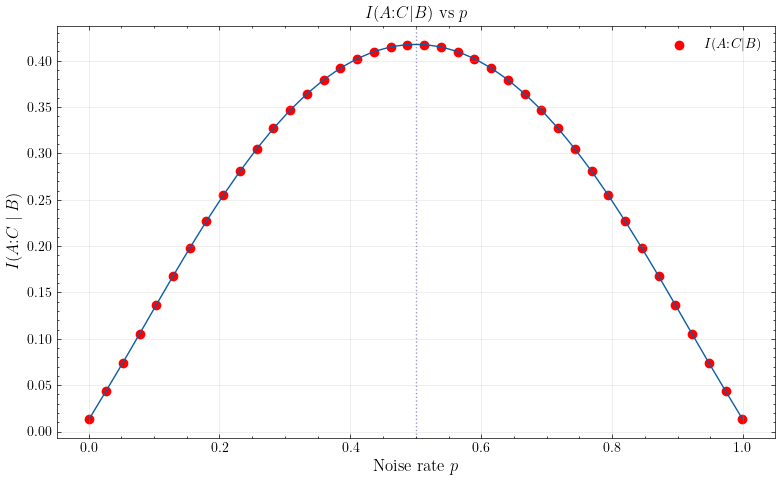

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_array, cmi_array, lw=1)
ax.scatter(p_array, cmi_array, color='red', label=r'$I(A{:}C|B)$')
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r'$I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_fib_ring.png", dpi=300)
plt.show()

## Markov-length calculation

This loop reuses one `FibonacciRingCMI` object per distance, so the expensive state construction and region precomputation are not repeated for every value of `p`.

In [24]:
def fit_markov_length_offset(distances, cmi_values, offset=0.0, threshold=1e-12):
    """Fit CMI(r) - offset = a exp(-r / xi)."""
    distances = np.asarray(distances, dtype=float)
    cmi_values = np.asarray(cmi_values, dtype=float)
    shifted = cmi_values - float(offset)
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])
    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan
    return -1.0 / slope


def regions_for_distance(d):
    """Original notebook's distance-dependent A,B,C regions."""
    d = int(d)
    A_d = list(range(1, 3))
    B_d = (list(range(0, 1))
           + list(range(3, 3 + d * 3 + 1))
           + list(range(3 + d * 3 + 3, 3 + d * 3 + 3 + d * 3)))
    C_d = list(range(3 + d * 3 + 1, 3 + d * 3 + 3))
    system_size = len(set(A_d + B_d + C_d))
    number_of_plaquettes = system_size // 3
    return A_d, B_d, C_d, system_size, number_of_plaquettes


p_array2 = np.linspace(0.001, 0.999, 40)
R_max = 4
# You can raise R_max; runtime grows with support size and compact region dimensions,
# but memory no longer scales as 4^N.
distances = np.arange(1, R_max + 1)

cmi_matrix = np.zeros((len(p_array2), len(distances)))
calculators = {}

for idd, d in enumerate(distances):
    A_d, B_d, C_d, system_size, P_d = regions_for_distance(d)
    calculators[d] = FibonacciRingCMI(P_d, A=A_d, B=B_d, C=C_d, error_sites=get_error_index(system_size))
    print(f"d={d}: {calculators[d].summary()}")

    for ip, p in enumerate(p_array2):
        cmi_matrix[ip, idd] = calculators[d].cmi(p)

xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=0.0)
    for ip in range(len(p_array2))
])

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))

d=1: {'plaquettes': 4, 'qubits': 12, 'support_size': 42, 'norm': 1.0000000000000002, 'region_dims': {'AB': 38, 'BC': 38, 'ABC': 42, 'B': 35}, 'number_of_trace_groups': {'AB': 2, 'BC': 2, 'ABC': 1, 'B': 4}}
d=2: {'plaquettes': 6, 'qubits': 18, 'support_size': 244, 'norm': 0.9999999999999999, 'region_dims': {'AB': 219, 'BC': 224, 'ABC': 244, 'B': 201}, 'number_of_trace_groups': {'AB': 2, 'BC': 2, 'ABC': 1, 'B': 4}}
d=3: {'plaquettes': 8, 'qubits': 24, 'support_size': 1344, 'norm': 1.0000000000000004, 'region_dims': {'AB': 1216, 'BC': 1248, 'ABC': 1344, 'B': 1128}, 'number_of_trace_groups': {'AB': 2, 'BC': 2, 'ABC': 1, 'B': 4}}
d=4: {'plaquettes': 10, 'qubits': 30, 'support_size': 7104, 'norm': 0.9999999999999976, 'region_dims': {'AB': 6456, 'BC': 6656, 'ABC': 7104, 'B': 6044}, 'number_of_trace_groups': {'AB': 2, 'BC': 2, 'ABC': 1, 'B': 4}}
xi_array:
[0.87526805 0.78311935 0.83070119 0.91072347 1.00282505 1.10150141
 1.20535411 1.31423541 1.42833686 1.54781794 1.67258481 1.8020944
 1.9351

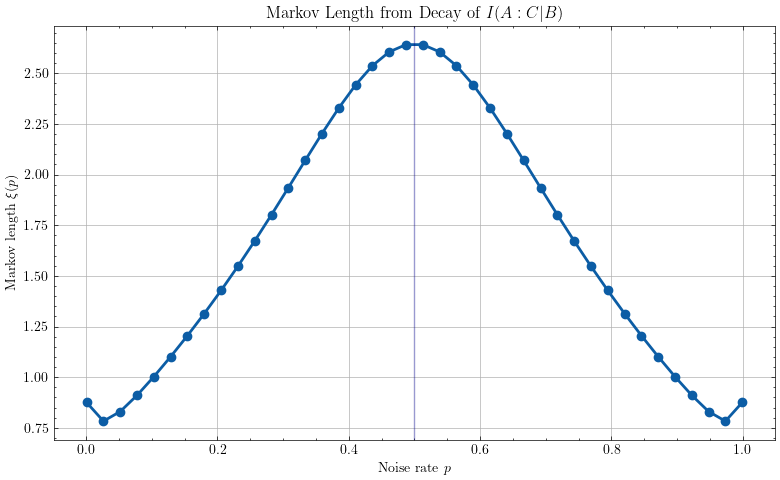

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(p_array2, xi_array, marker='o', lw=2)
plt.axvline(0.5, color='darkblue', ls='-', alpha=0.4)
plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"Markov length $\xi(p)$")
plt.title(r"Markov Length from Decay of $I(A:C|B)$")
plt.tight_layout()
plt.grid(True)
plt.savefig("New_plots/Xi_vs_p_fib_ring.png", dpi=300)
plt.show()

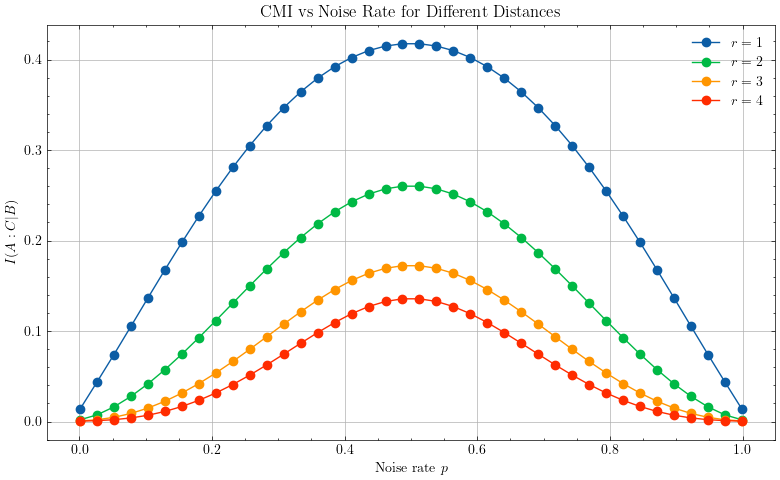

In [26]:
plt.figure(figsize=(8, 5))
for j, r in enumerate(distances):
    plt.plot(p_array2, cmi_matrix[:, j], marker='o', label=fr"$r={r}$")
plt.xlabel("Noise rate $p$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("CMI vs Noise Rate for Different Distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_different_r_fib_ring.png", dpi=300)
plt.show()

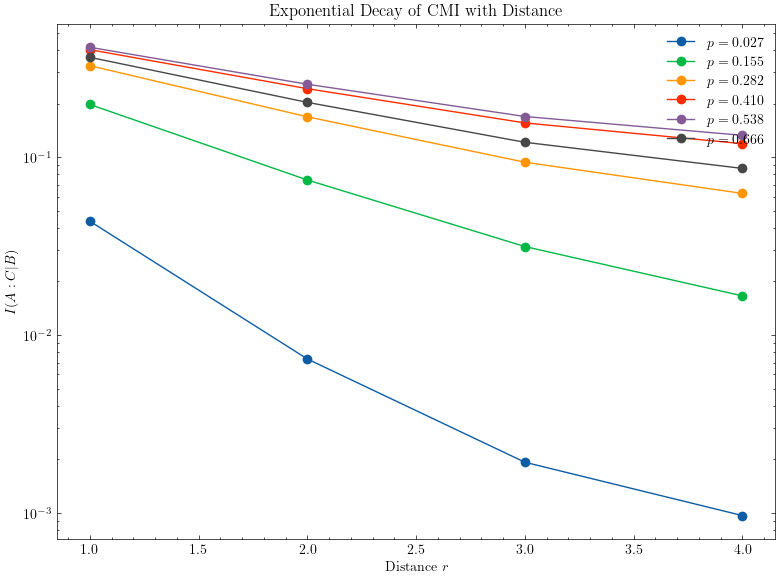

In [27]:
plt.figure(figsize=(8, 6))
for idx in range(1, 30, 5):
    y = cmi_matrix[idx]
    mask = y > 1e-12
    if np.any(mask):
        plt.plot(distances[mask], y[mask], marker='o', label=fr"$p={p_array2[idx]:.3f}$")
plt.yscale('log')
plt.xlabel("Distance $r$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("Exponential Decay of CMI with Distance")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("New_plots/CMI_decay_with_r_fib_ring.png", dpi=300)
plt.show()

## Optional JSON export

In [11]:
results = {
    "p_array": p_array.tolist(),
    "cmi_array": cmi_array.tolist(),
    "p_array2": p_array2.tolist(),
    "distances": distances.tolist(),
    "cmi_matrix": cmi_matrix.tolist(),
    "xi_array": xi_array.tolist(),
}
with open("fibonacci_ring_optimized_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved fibonacci_ring_optimized_results.json")

Saved fibonacci_ring_optimized_results.json
